# 13. DFT+U

An LDA or GGA functional is smooth in the occupation of a localised orbital, and it should
not be. The exact functional is piecewise linear in the electron number, with a derivative
discontinuity at every integer; a smooth approximation replaces those kinks by a curve, and
the curve's curvature is a **self-interaction**: it makes a half-occupied `d` orbital
cheaper than it should be, so charge that ought to localise spreads out instead. The
symptom is famous — transition-metal oxides that are insulators come out as metals.

DFT+U puts the kinks back, on a chosen set of orbitals. Dudarev's simplified
rotationally-invariant form (PRB **57**, 1505 (1998)) — QE's `lda_plus_u_kind = 0`, and
what is implemented here — adds

    E_U = sum_{I,s} (U_I/2) Tr[ n^{Is} - n^{Is} n^{Is} ]

where `n^{Is}` is the occupation *matrix* of atom `I`'s correlated manifold in spin channel
`s`. It is a penalty on fractional occupation and nothing else: zero when every eigenvalue
of `n` is 0 or 1, largest at 1/2.

This notebook shows what that means in practice — where the occupation matrix comes from,
why the choice of projector is the most consequential input, the potential as `jax.grad` of
the energy above, and then the physics on two systems: **fcc nickel**, small enough to run
four ways in a minute, and **antiferromagnetic FeO**, which is QE's own DFT+U benchmark.

At the end, the thing that comes free: **forces**. QE hand-derives them in `force_hub.f90`,
2552 lines. Here the Hubbard projectors are atomic orbitals centred on the atoms, so they
move when the atoms do, and differentiating the energy through that dependence is the whole
term.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pypresso.forces import compute_forces
from pypresso.hubbard.energy import (
    coefficients_from_setup, hubbard_energy, hubbard_potential, qe_hubbard_potential,
)
from pypresso.hubbard.manifold import build_hubbard_setup
from pypresso.io import read_qe_output
from pypresso.io.pwin import parse_pw_input, read_pw_input
from pypresso.pseudo import read_upf
from pypresso.scf import run_scf
from pypresso.scf.driver import Calculation
from pypresso.system import build_system
from pypresso.units import RY_TO_EV

PSEUDO = Path("../tests/data/pseudo")
GENERATED = Path("../tests/data/qe")
TESTSUITE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite")


def load(text):
    pwin = parse_pw_input(text)
    system = build_system(pwin)
    pseudos = tuple(read_upf(PSEUDO / s.pseudo_file) for s in system.structure.species)
    return pwin, system, pseudos


def scf(text, **options):
    pwin, system, pseudos = load(text)
    calculation = Calculation(system, pseudos)
    result = run_scf(
        system, pseudos, calculation=calculation, conv_thr=1e-10, max_iterations=250,
        mixing_beta=float(pwin.get("electrons", "mixing_beta", 0.7)),
        mixing_fixed_ns=int(pwin.get("electrons", "mixing_fixed_ns", 0)),
        **options,
    )
    return system, calculation, result


plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

## 1. The functional is a penalty on fractional occupation

For a single level with occupation `n` the correction is `(U/2)(n - n^2)`: a downward
parabola pinned to zero at both integers. Its derivative — the potential the orbital feels —
is `U(1/2 - n)`, which **pushes an under-occupied level up and an over-occupied one down**.
That discontinuous-looking slope at `n = 1/2` is where the derivative discontinuity of the
exact functional is being imitated.

U = 4.3 eV = 0.316044 Ry     max penalty per level = 0.537 eV


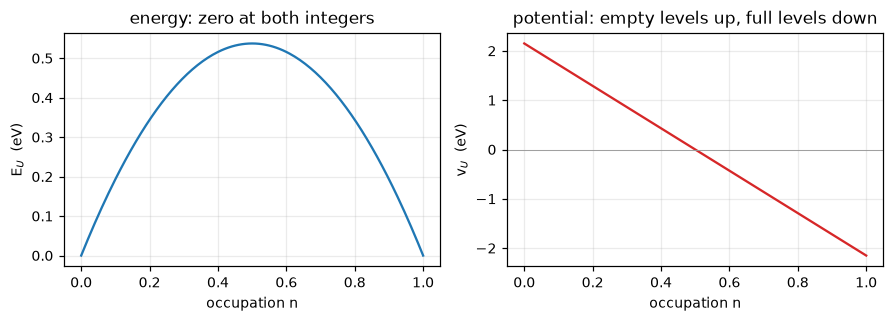

In [2]:
n = np.linspace(0.0, 1.0, 201)
u = 4.3 / RY_TO_EV  # the FeO benchmark's U, in Ry

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.0))
axes[0].plot(n, 0.5 * u * (n - n**2) * RY_TO_EV, color="C0")
axes[0].set_xlabel("occupation n"); axes[0].set_ylabel("E$_U$  (eV)")
axes[0].set_title("energy: zero at both integers")
axes[1].plot(n, u * (0.5 - n) * RY_TO_EV, color="C3")
axes[1].axhline(0.0, lw=0.6, color="0.6")
axes[1].set_xlabel("occupation n"); axes[1].set_ylabel("v$_U$  (eV)")
axes[1].set_title("potential: empty levels up, full levels down")
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()

print(f"U = 4.3 eV = {u:.6f} Ry     max penalty per level = {0.125 * u * RY_TO_EV:.3f} eV")

The matrix version is the same statement made basis-independently: `Tr[n - n n]` vanishes
when `n` is a projector (every eigenvalue 0 or 1) and is invariant under rotating the
manifold, which is what "rotationally invariant" means and why the correction does not
secretly pick out `d_{z^2}` over `d_{xy}`.

## 2. Which orbitals, and with what parameters

The `HUBBARD` card names a manifold by label — `Fe1-3d` — and the orbital that matches is
the one whose `PP_PSWFC` label in the pseudopotential is `3D`. That resolution, the
reference occupation, and two different offsets are all
`pypresso.hubbard.manifold`'s job (QE's `init_hubbard`, `determine_hubbard_occ` and
`offset_atom_wfc` between them).

The benchmark is antiferromagnetic FeO: two oxygens and two irons, the irons given
different *species names* so they can carry opposite starting moments.

**The card's numbers are in eV.** They are converted to Ry at the input boundary and
nothing downstream sees an eV again.

In [3]:
feo_input = (TESTSUITE / "pw_lda+U" / "lda+U.in").read_text()
print(feo_input[feo_input.index("HUBBARD"):])

pwin_feo, system_feo, pseudos_feo = load(feo_input)
setup = build_hubbard_setup(system_feo.hubbard, system_feo.structure, pseudos_feo)

print(f"projectors      {setup.projectors}")
print(f"correlated atoms{'':2s}{setup.atoms}   (0-based; the two irons)")
print(f"manifold width  {setup.ldims}   (2l+1 for l=2)")
print(f"offsetU         {setup.offsets}        <- position in the list of *Hubbard* orbitals")
print(f"oatwfc          {setup.atomwfc_offsets}       <- position in the list of *all* atomic orbitals")
print(f"nwfcU           {setup.nwfcU}")
print()
for slot, kind in enumerate(setup.types):
    item = setup.species[kind]
    name = system_feo.structure.species[kind].name
    print(f"  {name}: {item.n}{'spdf'[item.l]}   U = {item.u * RY_TO_EV:.2f} eV "
          f"= {item.u:.6f} Ry   reference occupation {item.occupation}")

HUBBARD {atomic}
U Fe1-3d 4.3
U Fe2-3d 4.3



projectors      atomic
correlated atoms  (2, 3)   (0-based; the two irons)
manifold width  (5, 5)   (2l+1 for l=2)
offsetU         (0, 5)        <- position in the list of *Hubbard* orbitals
oatwfc          (9, 15)       <- position in the list of *all* atomic orbitals
nwfcU           10

  Fe1: 3d   U = 4.30 eV = 0.316044 Ry   reference occupation 6.0
  Fe2: 3d   U = 4.30 eV = 0.316044 Ry   reference occupation 6.0


Two offsets, because there are two lists. Oxygen contributes `2s + 2p` = 4 atomic orbitals
and iron `4s + 3d` = 6, so the first iron's `3d` manifold starts at 4 + 4 + 1 = **9** in the
full atomic-orbital list — the list the orthogonalisation below runs over — and at **0** in
the list of Hubbard projectors, which is what `ns` is indexed by.

The reference occupation is 6, not the 7 the file says: `hubbard_occ(2,1) = 6.0` in the
input overrides it. It is only used to build the starting `ns`, by Hund's rule — majority
channel first.

In [4]:
from pypresso.hubbard.occupations import initial_ns

ns0 = initial_ns(setup, 2, system_feo.starting_magnetization)
print("starting ns, diagonal (init_ns):")
for slot, atom in enumerate(setup.atoms):
    up, down = np.diag(np.asarray(ns0)[0, slot]), np.diag(np.asarray(ns0)[1, slot])
    print(f"  atom {atom + 1}  up {np.round(up, 3)}  down {np.round(down, 3)}"
          f"   Tr = ({up.sum():.3f}, {down.sum():.3f})")
print()
print("QE prints, at its first iteration:")
print("  atom    3   Tr[ns(na)] (up, down, total) =   5.00000  1.00000  6.00000")

starting ns, diagonal (init_ns):
  atom 3  up [1. 1. 1. 1. 1.]  down [0.2 0.2 0.2 0.2 0.2]   Tr = (5.000, 1.000)
  atom 4  up [0.2 0.2 0.2 0.2 0.2]  down [1. 1. 1. 1. 1.]   Tr = (1.000, 5.000)

QE prints, at its first iteration:
  atom    3   Tr[ns(na)] (up, down, total) =   5.00000  1.00000  6.00000


## 3. The projectors, and the trap in the word "atomic"

`ns` is a projection, so it means nothing without saying *onto what*. QE offers several
sets; two are implemented here, and both start from the pseudo-atomic orbitals in the
pseudopotential file.

The trap is in the first one. `Hubbard_projectors = 'atomic'` reads as "use the orbitals as
they come", and that is not what QE does: `orthoUwfc` applies `s_psi` to them
unconditionally, so `wfcU = S phi` and the projection `<wfcU|psi>` is `<phi|S|psi>` — the
correct projection in the generalised metric an ultrasoft dataset lives in. With a
norm-conserving pseudopotential `S` is the identity and the distinction is invisible, which
is why testing on silicon would never find it.

`ortho-atomic` goes further: Löwdin-orthogonalise first, `wfcU = O^{-1/2} S phi` with
`O_ij = <phi_i|S|phi_j>`. **And `O` runs over every atomic orbital in the crystal**, not
over the Hubbard manifold alone.

In [5]:
nickel = (GENERATED / "ni-ldau-ortho.in").read_text()
_, system_ni, pseudos_ni = load(nickel)
calc_ni = Calculation(system_ni, pseudos_ni)

from pypresso.pseudo.atomic import atomic_wavefunctions

phi = atomic_wavefunctions(
    pseudos_ni, system_ni.structure, system_ni.cell,
    calc_ni.basis.smooth, calc_ni.basis.planewaves, system_ni.kpoints,
)[0]                                    # (natomwfc, npwx) at the first k-point
sphi = calc_ni._overlap(phi, 0)

plain = np.asarray(jnp.conj(phi) @ phi.T)
generalised = np.asarray(jnp.conj(phi) @ sphi.T)

print("nickel has", phi.shape[0], "atomic orbitals per atom: 4s + 3d")
print(f"<phi|phi>   diagonal: {np.round(np.diag(plain).real, 4)}")
print(f"<phi|S|phi> diagonal: {np.round(np.diag(generalised).real, 4)}")
print()
print(f"largest off-diagonal of <phi|S|phi>: {np.abs(generalised - np.diag(np.diag(generalised))).max():.4f}")
print("  -- the 4s and the 3d of the *same atom* are not orthogonal at a single k-point,")
print("     which is what O^{-1/2} is there to fix.")

nickel has 6 atomic orbitals per atom: 4s + 3d
<phi|phi>   diagonal: [9.8981 0.1514 0.218  0.218  0.1514 0.218 ]
<phi|S|phi> diagonal: [8.3061 0.8437 1.0323 1.0323 0.8437 1.0323]

largest off-diagonal of <phi|S|phi>: 0.1857
  -- the 4s and the 3d of the *same atom* are not orthogonal at a single k-point,
     which is what O^{-1/2} is there to fix.


Read the two diagonals together. Neither is supposed to be 1 — these are Bloch sums at a
single k-point, so an orbital that spills into the neighbouring cells picks up their overlap
(the diffuse `4s`, well above 1) and one that is hard picks up the plane-wave truncation
instead (the `3d`, at 0.15–0.22 with `ecutwfc = 24 Ry`). What matters is what `S` does to
them: it lifts the `3d` columns from 0.15–0.22 to **0.84–1.03**, which is the ultrasoft
augmentation charge putting back exactly the norm the pseudisation removed. That is the
projection `<phi|S|psi>` measures and `<phi|psi>` does not, and it is why `atomic` and
`ortho-atomic` are different calculations rather than different spellings — the overlap is
not the identity, and `S` moves it by a lot.

Now the second trap, and it took a wrong answer to find. QE renormalises the atomic
orbitals **as it reads the file** (`upf_check_atwfc_norm`, called from
`Modules/read_pseudo.f90`), and it does so in the *generalised* metric:

    norm^2 = int (r chi)^2 dr + sum_ij q_ij <beta_i|chi><beta_j|chi>

Nickel's `4s` fails that test in the file — QE prints `wavefunction(s) 4S renormalized` —
and so does iron's. For the starting wavefunctions this is irrelevant (they get rotated
anyway). For `atomic` projectors on a `3d` manifold it is irrelevant too. For
`ortho-atomic` it is not: the `4s` is *in* the matrix whose inverse square root produces the
`3d` projectors.

In [6]:
import xml.etree.ElementTree as ET
from pypresso.pseudo.radial import simpson_weights

# The file's own chi, before pypresso applies QE's renormalisation.
root = ET.parse(PSEUDO / "Ni.pz-nd-rrkjus.UPF").getroot()
raw = {node.attrib["label"].upper(): np.array(node.text.split(), dtype=float)
       for node in root.iter() if node.tag.startswith("PP_CHI")}

pseudo = read_upf(PSEUDO / "Ni.pz-nd-rrkjus.UPF")
weights = np.asarray(simpson_weights(pseudo.rab))
q = np.asarray(pseudo.augmentation.q)


def generalised_norm(chi, l):
    value = float(np.sum(chi * chi * weights))
    overlaps = np.zeros(len(pseudo.projectors))
    for i, beta in enumerate(pseudo.projectors):
        if beta.l != l:
            continue
        cut = beta.cutoff_index
        overlaps[i] = float(np.sum(beta.beta[:cut] * chi[:cut] * weights[:cut]))
    return value + float(overlaps @ q @ overlaps)


for orbital in pseudo.orbitals:
    before = generalised_norm(raw[orbital.label], orbital.l)
    after = generalised_norm(np.asarray(orbital.chi), orbital.l)
    print(f"  {orbital.label}:  <chi|S|chi> in the file {before:.6f}   after reading {after:.6f}")
print()
print("QE's own message for this file:  'wavefunction(s)  4S renormalized'")

  4S:  <chi|S|chi> in the file 0.886314   after reading 1.000000
  3D:  <chi|S|chi> in the file 1.000000   after reading 1.000000

QE's own message for this file:  'wavefunction(s)  4S renormalized'


The cost of skipping that renormalisation, measured: **4e-3** in `Tr[ns]` and **7e-4 Ry** in
nickel's total energy with `ortho-atomic` projectors — small enough to be mistaken for a
convergence difference and large enough to be wrong. With the renormalisation the same run
agrees with QE to 2e-9 Ry (§5).

## 4. The potential is the gradient, not a second derivation

The project rule (`PLAN.md` D1): write the energy, get the potential from `jax.grad`. QE's
`v_hubbard` — four nested loops of hand-derived algebra — is then transcribed as a **test**
rather than as the implementation. The two share nothing but the occupation matrix.

In [7]:
import copy

check = copy.deepcopy(setup)
for item in check.species:                       # a case with every term switched on
    if item is not None:
        item.u, item.j0, item.alpha, item.beta = 0.30, 0.05, 0.02, 0.03
coefficients = coefficients_from_setup(check)

rng = np.random.default_rng(0)
block = rng.normal(size=(2, check.nslot, check.ldmx, check.ldmx))
ns = jnp.asarray(0.5 * (block + block.transpose(0, 1, 3, 2)))

by_grad = np.asarray(hubbard_potential(ns, coefficients))
by_hand = qe_hubbard_potential(ns, check)
print(f"max |jax.grad(E_U)  -  v_hubbard.f90|  =  {np.abs(by_grad - by_hand).max():.3e}")

max |jax.grad(E_U)  -  v_hubbard.f90|  =  1.110e-16


Zero to machine precision, `U`, `J0`, `alpha` and `beta` all active.

One thing that identity *hides*, and it is the most expensive detail in the phase: **with
`nspin = 1` the energy carries a factor of two and the potential does not.** `new_ns` halves
`ns` when there is one channel, so `ns` always means one channel's occupation; `eth` is then
doubled because there are two identical channels, while `v_hub` acts on one channel at a
time and is not. Differentiating the *doubled* energy gives a potential twice too large —
and an SCF that converges beautifully to the wrong number.

In [8]:
# ``beta`` is switched off for this one: it is the single term that carries
# sgn(s), so it is the single place where two *identical* channels are not
# interchangeable -- it cancels between them where every other term adds.
without_beta = copy.deepcopy(check)
for item in without_beta.species:
    if item is not None:
        item.beta = 0.0
plain = coefficients_from_setup(without_beta)

one = jnp.asarray(np.asarray(ns)[:1])
two = jnp.concatenate([one, one])           # the same occupations in two channels

print(f"E_U(one channel, doubled) = {float(hubbard_energy(one, plain)):+.8f} Ry")
print(f"E_U(the two channels)     = {float(hubbard_energy(two, plain)):+.8f} Ry")
print()
print("...and the potential is per channel, so it is *not* doubled:")
print(f"  max |v(one channel) - v(channel 1 of two)| = "
      f"{np.abs(np.asarray(hubbard_potential(one, plain))[0] - np.asarray(hubbard_potential(two, plain))[0]).max():.3e}")

E_U(one channel, doubled) = -5.85254882 Ry
E_U(the two channels)     = -5.85254882 Ry

...and the potential is per channel, so it is *not* doubled:


  max |v(one channel) - v(channel 1 of two)| = 0.000e+00


## 5. Nickel, four ways

fcc nickel, one atom, `U = 3 eV` on the `3d` shell. Four runs: no U at all, `atomic`
projectors unpolarized, `ortho-atomic` polarized, and `atomic` with `J0 = 1 eV`. Each is
compared against the vendored `pw.x` at the same `conv_thr = 1e-10`.

In [9]:
import time

NICKEL = {
    "U -> 0": None,
    "atomic, nspin=1": "ni-ldau-nospin",
    "ortho-atomic": "ni-ldau-ortho",
    "atomic + J0": "ni-ldau-j0",
}

# The first run keeps the card and sets U to 1e-8 eV rather than dropping it, so
# that its occupation matrix is measured through the *same* ortho-atomic
# projectors as the U = 3 eV run below. That makes the two comparable, and it is
# the null test besides: every line of the machinery runs and must change nothing.
null = (GENERATED / "ni-ldau-ortho.in").read_text().replace("U Ni-3d 3.0", "U Ni-3d 1.d-8")

runs = {}
for label, stem in NICKEL.items():
    text = null if stem is None else (GENERATED / f"{stem}.in").read_text()
    started = time.time()
    runs[label] = (*scf(text), None if stem is None
                   else read_qe_output(GENERATED / f"reference.out.{stem}"))
    print(f"  {label:18s} {time.time() - started:5.1f} s   "
          f"{runs[label][2].iterations:3d} iterations")

  U -> 0               8.3 s    13 iterations


  atomic, nspin=1      4.8 s    13 iterations


  ortho-atomic         5.4 s    12 iterations


  atomic + J0          6.1 s    14 iterations


In [10]:
header = f"{'':18s} {'E (Ry)':>17s} {'QE (Ry)':>17s} {'diff':>10s} {'E_U (Ry)':>11s} {'QE E_U':>11s}"
print(header); print("-" * len(header))
for label, (_, _, result, reference) in runs.items():
    eu = result.energy_terms.get("hubbard", 0.0)
    if reference is None:
        print(f"{label:18s} {result.total_energy:17.9f} {'-':>17s} {'-':>10s} {eu:11.8f} {'-':>11s}")
        continue
    qe_eu = reference.energy_terms["hubbard"]
    print(f"{label:18s} {result.total_energy:17.9f} {reference.total_energy:17.9f} "
          f"{result.total_energy - reference.total_energy:10.2e} {eu:11.8f} {qe_eu:11.8f}")

                              E (Ry)           QE (Ry)       diff    E_U (Ry)      QE E_U
-----------------------------------------------------------------------------------------
U -> 0                 -85.723399012                 -          -  0.00000000           -
atomic, nspin=1        -85.654113756     -85.654113750  -6.49e-09  0.06081074  0.06081088
ortho-atomic           -85.628386898     -85.628386900   2.03e-09  0.09119025  0.09118988
atomic + J0            -85.360875234     -85.360875230  -3.53e-09  0.36240130  0.36240132


Nine decimal places, on three different projector/spin combinations (the first row is the
null run and has no QE counterpart). The `nspin = 1` row is
the only one in the whole suite that tests the factor of two above; every polarized case
passes with or without it.

What the correction does to the occupation matrix is the physics. Its eigenvalues are the
occupations of the natural orbitals of the `3d` shell, and `E_U` pushes them towards 0 and 1:

  U -> 0         Tr[ns] = (4.83352, 4.09390)  total 8.92741   moment 0.784 mu_B
  ortho-atomic   Tr[ns] = (4.85478, 4.13592)  total 8.99070   moment 0.770 mu_B


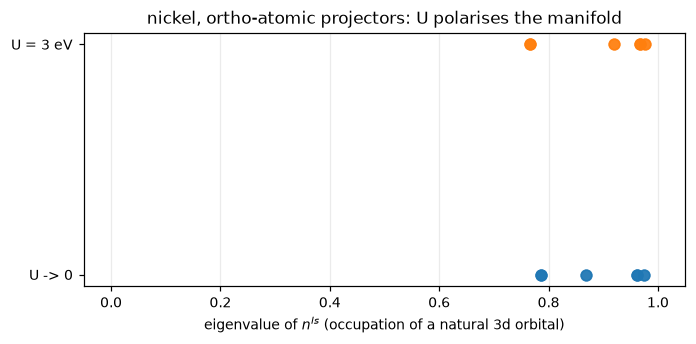

In [11]:
fig, ax = plt.subplots(figsize=(6.4, 3.2))
for offset, (label, key) in enumerate([("U -> 0", "U -> 0"), ("U = 3 eV", "ortho-atomic")]):
    result = runs[key][2]
    values = np.concatenate([
        np.linalg.eigvalsh(np.asarray(result.ns)[s, 0]) for s in range(result.ns.shape[0])
    ])
    ax.plot(values, np.full_like(values, offset), "o", ms=7, alpha=0.75, label=label)
ax.set_yticks([0, 1]); ax.set_yticklabels(["U -> 0", "U = 3 eV"])
ax.set_xlabel("eigenvalue of $n^{Is}$ (occupation of a natural 3d orbital)")
ax.set_xlim(-0.05, 1.05); ax.grid(alpha=0.25, axis="x")
ax.set_title("nickel, ortho-atomic projectors: U polarises the manifold")
fig.tight_layout()

for label in ("U -> 0", "ortho-atomic"):
    result = runs[label][2]
    traces = result.hubbard_occupations[0]
    print(f"  {label:14s} Tr[ns] = ({traces[0]:.5f}, {traces[1]:.5f})  total {traces[2]:.5f}"
          f"   moment {result.absolute_magnetization:.3f} mu_B")

## 6. FeO: the case DFT+U exists for

Antiferromagnetic FeO, QE's own `pw_lda+U` benchmark: `U = 4.3 eV` on both iron
sublattices, ultrasoft, `nspin = 2`, a symmetry-reduced 2x2x2 k-set — so the occupation
matrix has to be symmetrised, exactly as `becsum` does, or the two irons come out
inequivalent.

The null test runs first: the same input with `U = 1e-8 eV`. Every line of the machinery
executes — projectors built, `ns` measured, symmetrised and mixed, the term in the
Hamiltonian — and the answer must be the plain LSDA one. A sign error in the projection is
invisible here and fatal everywhere below, which is what makes it worth the minute.

In [12]:
FEO = {
    "U = 1e-8 (null test)": "lda+U-noU.in",
    "U = 4.3 eV": "lda+U.in",
    "U = 4.3 eV, steered ns": "lda+U-user_ns.in",
}

feo = {}
for label, name in FEO.items():
    started = time.time()
    reference = read_qe_output(GENERATED / f"reference.out.pw_lda+U-{Path(name).stem}")
    feo[label] = (*scf((TESTSUITE / "pw_lda+U" / name).read_text()), reference)
    print(f"  {label:24s} {time.time() - started:5.1f} s   "
          f"{feo[label][2].iterations:3d} iterations")

  U = 1e-8 (null test)      61.7 s    35 iterations


  U = 4.3 eV                89.6 s    53 iterations


  U = 4.3 eV, steered ns    65.6 s    35 iterations


In [13]:
header = (f"{'':24s} {'E (Ry)':>16s} {'QE (Ry)':>16s} {'diff':>10s} "
          f"{'E_U (Ry)':>11s} {'QE E_U':>11s} {'|m| (mu_B)':>11s}")
print(header); print("-" * len(header))
for label, (_, _, result, reference) in feo.items():
    print(f"{label:24s} {result.total_energy:16.8f} {reference.total_energy:16.8f} "
          f"{result.total_energy - reference.total_energy:10.2e} "
          f"{result.energy_terms['hubbard']:11.8f} {reference.energy_terms['hubbard']:11.8f} "
          f"{result.absolute_magnetization:11.3f}")
print()
for label, (_, _, result, _) in feo.items():
    line = "   ".join(
        f"atom {atom + 1}: {t[0]:.4f} / {t[1]:.4f}"
        for atom, t in result.hubbard_occupations.items()
    )
    print(f"  {label:24s} Tr[ns] up/down   {line}")

                                   E (Ry)          QE (Ry)       diff    E_U (Ry)      QE E_U  |m| (mu_B)
---------------------------------------------------------------------------------------------------------
U = 1e-8 (null test)        -174.82465795    -174.82465795   3.44e-09  0.00000000  0.00000000       7.087
U = 4.3 eV                  -174.47156068    -174.47156067  -6.70e-09  0.31370493  0.31370472       7.248
U = 4.3 eV, steered ns      -174.53741692    -174.53741692  -3.71e-09  0.19617811  0.19617796       7.315

  U = 1e-8 (null test)     Tr[ns] up/down   atom 3: 4.9703 / 1.9687   atom 4: 1.9687 / 4.9703
  U = 4.3 eV               Tr[ns] up/down   atom 3: 4.9911 / 1.8454   atom 4: 1.8454 / 4.9911
  U = 4.3 eV, steered ns   Tr[ns] up/down   atom 3: 4.9924 / 1.7737   atom 4: 1.7737 / 4.9924


The two irons come out as each other's mirror image — 4.99/1.85 against 1.85/4.99 — which
is the antiferromagnet, and it is the symmetrisation that makes them exactly so on a
reduced k-set.

Look at the third row. It is the **same input** as the second except for two
`starting_ns_eigenvalue` lines, and it converges 66 mRy lower, to a different
self-consistent state. That is not a bug in either code: a magnetic insulator's occupation
matrix has more than one fixed point, and `ns_adj` is how a particular one is asked for.

The timing of `ns_adj` is a trap of its own. QE runs `init_ns` before the loop and
`ns_adj` **after the first iteration**, on the `ns` *measured* from the first
diagonalisation — replacing both the input and the output copy. Applying it to the
Hund's-rule starting matrix instead steers the first Hamiltonian rather than the second,
and lands back on the other solution.

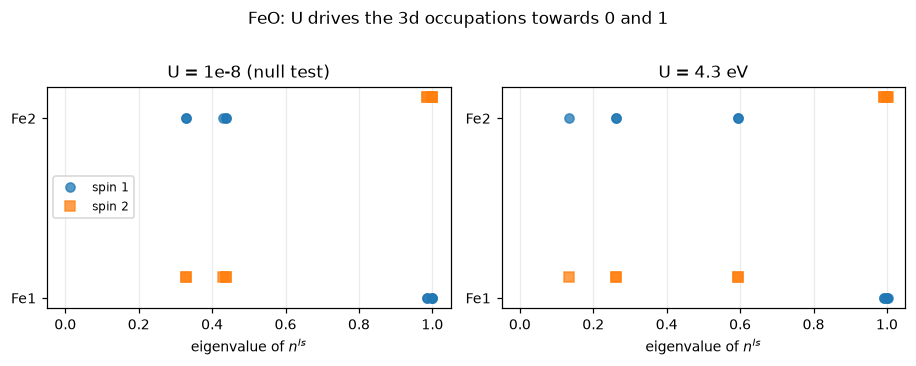

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.2), sharex=True)
for ax, (label, key) in zip(axes, [("U = 1e-8 (null test)", 0), ("U = 4.3 eV", 1)]):
    result = feo[label][2]
    for slot, atom in enumerate(result.hubbard_setup.atoms):
        for spin, marker in enumerate("os"):
            values = np.linalg.eigvalsh(np.asarray(result.ns)[spin, slot])
            ax.plot(values, np.full_like(values, slot + 0.12 * spin), marker,
                    ms=6, alpha=0.75,
                    color=f"C{spin}", label=f"spin {spin + 1}" if slot == 0 else None)
    ax.set_title(label); ax.set_xlim(-0.05, 1.05); ax.grid(alpha=0.25, axis="x")
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Fe1", "Fe2"])
    ax.set_xlabel("eigenvalue of $n^{Is}$")
axes[0].legend(loc="center left", fontsize=8)
fig.suptitle("FeO: U drives the 3d occupations towards 0 and 1", y=1.02)
fig.tight_layout()

The majority channel is already integer-filled in both — around 0.99, and it costs nothing
either way. It is the **minority** channel that the correction acts on. Without U its five
eigenvalues sit at 0.33, 0.33, 0.43, 0.44, 0.44: fractional, all of them, which is precisely
the configuration the functional is written to penalise. With `U = 4.3 eV` the same five
split to 0.13, 0.26, 0.26, 0.59, 0.59 — the low ones pushed towards empty and the high ones
towards full. That is the manifold beginning to localise, and the total `Tr[ns]` falls from
6.94 to 6.84 as the charge that was sitting in half-filled orbitals leaves.

## 7. Forces, for free

The Hubbard energy depends on the atomic positions because the projectors are atomic
orbitals *centred on the atoms*. QE derives that dependence by hand in `force_hub.f90` —
2552 lines, and with `ortho-atomic` projectors it has to carry `d(O^{-1/2})/d tau` as well.

Here `Calculation.at_positions` rebuilds the projectors at new positions and
`pypresso.forces.energy` measures `ns` through them, so `jax.grad` of the total energy
produces the term with nothing written down for it. QE's `pw_lda+U/lda+U_force.in`
displaces both irons along the body diagonal and prints the force.

In [15]:
from pypresso.forces.energy import state_from_result

force_input = (TESTSUITE / "pw_lda+U" / "lda+U_force.in").read_text()
system_f, calc_f, result_f = scf(force_input)
reference_f = read_qe_output(GENERATED / "reference.out.pw_lda+U-lda+U_force")

forces = np.asarray(compute_forces(calc_f, result_f, method="autodiff").forces)
print(f"total energy  {result_f.total_energy:.9f} Ry   QE {reference_f.total_energy:.9f}"
      f"   diff {result_f.total_energy - reference_f.total_energy:.2e}")
print()
print(f"{'atom':>5s}  {'pypresso (Ry/bohr)':>34s}   {'QE (Ry/bohr)':>34s}")
for atom, (mine, theirs) in enumerate(zip(forces, reference_f.forces)):
    print(f"{atom + 1:5d}  {np.array2string(mine, precision=7, sign='+'):>34s}   "
          f"{np.array2string(theirs, precision=7, sign='+'):>34s}")
print(f"\nlargest difference: {np.abs(forces - reference_f.forces).max():.2e} Ry/bohr")

total energy  -174.357111006 Ry   QE -174.357111000   diff -5.56e-09

 atom                  pypresso (Ry/bohr)                         QE (Ry/bohr)
    1  [+2.0920786e-13 +2.0920786e-13 +2.0920786e-13]         [+6.3e-07 +6.3e-07 +6.3e-07]
    2  [-2.752491e-13 -2.752491e-13 -2.752491e-13]            [+5.e-08 +5.e-08 +5.e-08]
    3  [-0.1418888 -0.1418888 -0.1418888]   [-0.1418937 -0.1418937 -0.1418937]
    4  [+0.1418888 +0.1418888 +0.1418888]      [+0.141893 +0.141893 +0.141893]

largest difference: 4.83e-06 Ry/bohr


In [16]:
# How much of that force *is* the Hubbard term: differentiate E_U alone.
from pypresso.system.symmetry import atom_mapping, symmetrize_vector

state = state_from_result(result_f)


def hubbard_only(positions):
    moved = calc_f.at_positions(positions)
    return hubbard_energy(
        moved.occupation_matrix(state.wavefunctions, state.weights),
        moved.hubbard_coefficients,
    )


raw = -np.asarray(jax.grad(hubbard_only)(calc_f.system.structure.positions))
# The same ``symvector`` the total force goes through, and for the same reason:
# a gradient built from wavefunctions on the irreducible wedge has components
# along directions the crystal's symmetry forbids.
mapping = atom_mapping(calc_f.system.cell, calc_f.system.structure, calc_f.symmetries)
f_hub = np.asarray(symmetrize_vector(
    raw, calc_f.system.cell, calc_f.symmetries, mapping
))

print("the Hubbard contribution alone (QE's force_hub):")
for atom, row in enumerate(f_hub):
    print(f"  atom {atom + 1}  {np.array2string(row, precision=6, sign='+')}")
print(f"\n  before symmetrisation, atom 3: "
      f"{np.array2string(raw[2], precision=6, sign='+')}")
print(f"  |force_hub| / |total force| = "
      f"{np.abs(f_hub).max() / np.abs(forces).max():.3f}")

the Hubbard contribution alone (QE's force_hub):
  atom 1  [-2.268403e-17 -2.268403e-17 -2.268403e-17]
  atom 2  [+1.291813e-16 +1.291813e-16 +1.291813e-16]
  atom 3  [+0.006911 +0.006911 +0.006911]
  atom 4  [-0.006911 -0.006911 -0.006911]

  before symmetrisation, atom 3: [+0.008655 +0.004239 +0.007839]
  |force_hub| / |total force| = 0.049


A few percent of the force on the irons — small here because the displacement is small, and
still more than a thousand times the 4.8e-6 Ry/bohr the total agrees with QE to. It comes out of a term nobody wrote down.

The raw gradient printed underneath is worth a second look: it is *not* along the body
diagonal, which the symmetry of this crystal requires of any force. That is not an error in
the term — it is the same thing `symvector` exists for everywhere else. The frozen
wavefunctions come from the irreducible wedge, so a gradient taken through them carries
components along directions the crystal forbids, and they are projected out at the end. The
total force above went through exactly that step, which is why it was already clean.

The transcribed force path deliberately has no `force_hub` and **refuses** rather than
returning a force that is short by this much:

```python
compute_forces(calc_f, result_f, method="analytic")
# NotImplementedError: the analytic force expressions do not include force_hub; ...
```

## 8. What is here, and what is not

Everything above is QE's `lda_plus_u_kind = 0`. The variants that are *refused by name*,
rather than silently approximated, are: the full Liechtenstein formulation
(`J`, `B`, `E2`, `E3`), the intersite `V`, background channels, the orbital-resolved
variant, the `wf` and `pseudo` projector sets, noncollinear `ns_nc`, and DFT+U on a spin
spiral. Each raises at input-parsing or setup time, because a Hubbard functional that runs
and is not the one asked for is the failure mode this codebase is built to avoid.

In [17]:
summary = []
for label, (_, _, result, reference) in list(runs.items())[1:] + list(feo.items()):
    summary.append((label, result.total_energy - reference.total_energy,
                    result.energy_terms["hubbard"] - reference.energy_terms["hubbard"]))
summary.append(("FeO forces (lda+U_force)", result_f.total_energy - reference_f.total_energy,
                result_f.energy_terms["hubbard"] - reference_f.energy_terms["hubbard"]))

print(f"{'case':26s} {'total - QE (Ry)':>18s} {'E_U - QE (Ry)':>16s}")
print("-" * 62)
for label, de, du in summary:
    print(f"{label:26s} {de:18.2e} {du:16.2e}")
print("-" * 62)
print(f"{'worst':26s} {max(abs(d) for _, d, _ in summary):18.2e} "
      f"{max(abs(d) for _, _, d in summary):16.2e}")

case                          total - QE (Ry)    E_U - QE (Ry)
--------------------------------------------------------------
atomic, nspin=1                     -6.49e-09        -1.42e-07
ortho-atomic                         2.03e-09         3.69e-07
atomic + J0                         -3.53e-09        -1.82e-08
U = 1e-8 (null test)                 3.44e-09         8.89e-10
U = 4.3 eV                          -6.70e-09         2.07e-07
U = 4.3 eV, steered ns              -3.71e-09         1.53e-07
FeO forces (lda+U_force)            -5.56e-09         4.52e-07
--------------------------------------------------------------
worst                                6.70e-09         4.52e-07
